Module to run the diffusion model (using Wavestitch)

In [1]:
"""import cell"""

# import argparse
import os
import yaml
from timeit import default_timer as timer
from types import SimpleNamespace
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import from_numpy, optim, nn, randint, normal, sqrt, device, save
from torch.utils.data import TensorDataset, DataLoader, random_split
from data_utils import Preprocessor
import pandas as pd
import polars as pl
from training_utils import MyDataset, fetchModel, fetchDiffusionConfig

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sys
sys.path.append("..")
import autoencoder as ae
from utils import DimensionalityEstimator, get_frechet_distance, Losses


CUDA extension for cauchy multiplication not found. Install by going to extensions/cauchy/ and running `python setup.py install`. This should speed up end-to-end training by 10-50%
Using device: cuda


In [2]:
"""get diffusion config params + set dataset"""

dataset = "RossmanSales" # "RossmanSales", "BeijingAirQuality", "", "", "PanamaElectricity"


with open('wavestitch_params.yaml', 'r') as wavestitch_file:
    wavestitch_yaml = yaml.safe_load(wavestitch_file)
backbone            = wavestitch_yaml['shared']['backbone']
random_seed         = wavestitch_yaml['shared']['random_seed']
beta_0              = wavestitch_yaml['shared']['beta_0']
beta_T              = wavestitch_yaml['shared']['beta_T']
timesteps           = wavestitch_yaml['shared']['timesteps']
hdim                = wavestitch_yaml['shared']['hdim']
lr                  = wavestitch_yaml['shared']['lr']
batch_size          = wavestitch_yaml['shared']['batch_size']
layers              = wavestitch_yaml['shared']['layers']
window_size         = wavestitch_yaml['shared']['window_size']
stride              = wavestitch_yaml['shared']['stride']
num_res_layers      = wavestitch_yaml['shared']['num_res_layers']
res_channels        = wavestitch_yaml['shared']['res_channels']
skip_channels       = wavestitch_yaml['shared']['skip_channels']
diff_step_embed_in  = wavestitch_yaml['shared']['diff_step_embed_in']
diff_step_embed_mid = wavestitch_yaml['shared']['diff_step_embed_mid']
diff_step_embed_out = wavestitch_yaml['shared']['diff_step_embed_out']
s4_lmax             = wavestitch_yaml['shared']['s4_lmax']
s4_dstate           = wavestitch_yaml['shared']['s4_dstate']
s4_dropout          = wavestitch_yaml['shared']['s4_dropout']
s4_bidirectional    = wavestitch_yaml['shared']['s4_bidirectional']
s4_layernorm        = wavestitch_yaml['shared']['s4_layernorm']
propCycEnc          = wavestitch_yaml['shared']['propCycEnc']
epochs              = 100 #wavestitch_yaml['training']['epochs']
synth_mask          = wavestitch_yaml['synthesis']['synth_mask']
n_trials            = wavestitch_yaml['synthesis']['n_trials']


In [3]:
"""OLD Wavestitch"""

# np.random.seed(42)
# torch.manual_seed(42)
# parser = argparse.ArgumentParser()
# parser.add_argument('-dataset', '-d', type=str,
#                     help='MetroTraffic, BeijingAirQuality, AustraliaTourism, RossmanSales, PanamaEnergy', required=True)
# parser.add_argument('-backbone', type=str, help='Transformer, Bilinear, Linear, S4', default='S4')
# parser.add_argument('-beta_0', type=float, default=0.0001, help='initial variance schedule')
# parser.add_argument('-beta_T', type=float, default=0.02, help='last variance schedule')
# parser.add_argument('-timesteps', '-T', type=int, default=200, help='training/inference timesteps')
# parser.add_argument('-hdim', type=int, default=64, help='hidden embedding dimension')
# parser.add_argument('-lr', type=float, default=1e-4, help='learning rate')
# parser.add_argument('-batch_size', type=int, help='batch size', default=1024)
# parser.add_argument('-epochs', type=int, default=1000, help='training epochs')
# parser.add_argument('-layers', type=int, default=4, help='number of hidden layers')
# parser.add_argument('-window_size', type=int, default=32, help='the size of the training windows')
# parser.add_argument('-stride', type=int, default=1, help='the stride length to shift the training window by')
# parser.add_argument('-num_res_layers', type=int, default=4, help='the number of residual layers')
# parser.add_argument('-res_channels', type=int, default=64, help='the number of res channels')
# parser.add_argument('-skip_channels', type=int, default=64, help='the number of skip channels')
# parser.add_argument('-diff_step_embed_in', type=int, default=32, help='input embedding size diffusion')
# parser.add_argument('-diff_step_embed_mid', type=int, default=64, help='middle embedding size diffusion')
# parser.add_argument('-diff_step_embed_out', type=int, default=64, help='output embedding size diffusion')
# parser.add_argument('-s4_lmax', type=int, default=100)
# parser.add_argument('-s4_dstate', type=int, default=64)
# parser.add_argument('-s4_dropout', type=float, default=0.0)
# parser.add_argument('-s4_bidirectional', type=bool, default=True)
# parser.add_argument('-s4_layernorm', type=bool, default=True)
# parser.add_argument('-propCycEnc', type=bool, default=False)
# args = parser.parse_args()
# dataset = args.dataset
# device = device('cuda' if torch.cuda.is_available() else 'cpu')
# preprocessor = Preprocessor(dataset, args.propCycEnc)
# df = preprocessor.df_cleaned
# training_df = df.loc[preprocessor.train_indices]
# test_df = df.loc[preprocessor.test_indices]
# hierarchical_column_indices = training_df.columns.get_indexer(preprocessor.hierarchical_features_cyclic)
# # training_samples = []
# d_vals_tensor = from_numpy(training_df.values)
# training_samples = d_vals_tensor.unfold(0, args.window_size, 1).transpose(1, 2)
# # masks = m_vals_tensor.unfold(0, args.window_size, 1)
# # for i in range(0, len(training_df) - args.window_size + 1, args.stride):
# #     window = training_df.iloc[i:i + args.window_size].values
# #     training_samples.append(window)
# in_dim = len(training_df.columns)
# out_dim = len(training_df.columns) - len(hierarchical_column_indices)
# training_dataset = MyDataset(training_samples.float())
# model = fetchModel(in_dim, out_dim, args).to(device)
# diffusion_config = fetchDiffusionConfig(args)
# optimizer = optim.Adam(model.parameters(), lr=args.lr)
# criterion = nn.MSELoss()
# dataloader = DataLoader(training_dataset, batch_size=args.batch_size, shuffle=True)
# all_indices = np.arange(len(training_df.columns))

# # Find the indices not in the index_list
# remaining_indices = np.setdiff1d(all_indices, hierarchical_column_indices)

# # Convert to an ndarray
# non_hier_cols = np.array(remaining_indices)
# """TRAINING"""
# for epoch in range(args.epochs):
#     total_loss = 0.0
#     for batch in dataloader:
#         batch = batch.to(device)
#         timesteps = randint(diffusion_config['T'], size=(batch.shape[0],)).to(device)
#         sigmas = normal(0, 1, size=batch.shape).to(device)
#         """Forward noising"""
#         alpha_bars = diffusion_config['alpha_bars'].to(device)
#         coeff_1 = sqrt(alpha_bars[timesteps]).reshape((len(timesteps), 1, 1))
#         coeff_2 = sqrt(1 - alpha_bars[timesteps]).reshape((len(timesteps), 1, 1))
#         conditional_mask = np.ones(batch.shape)
#         conditional_mask[:, :, non_hier_cols] = 0
#         conditional_mask = from_numpy(conditional_mask).float().to(device)
#         batch_noised = (1 - conditional_mask) * (coeff_1 * batch + coeff_2 * sigmas) + conditional_mask * batch
#         batch_noised = batch_noised.to(device)
#         timesteps = timesteps.reshape((-1, 1))
#         # timesteps = timesteps.to(device)
#         sigmas_predicted = model(batch_noised, timesteps)
#         optimizer.zero_grad()
#         sigmas_permuted = sigmas[:, :, non_hier_cols].permute((0, 2, 1))
#         sigmas_permuted = sigmas_permuted.to(device)
#         loss = criterion(sigmas_predicted, sigmas_permuted)
#         loss.backward()
#         total_loss += loss
#         optimizer.step()
#     print(f'epoch: {epoch}, loss: {total_loss}')
# path = f'saved_models/{args.dataset}/'
# if args.propCycEnc:
#     filename = "model_prop.pth"
# else:
#     filename = "model.pth"
# filepath = os.path.join(path, filename)

# if not os.path.exists(path):
#     os.makedirs(path)
# torch.save(model.state_dict(), filepath)


'OLD Wavestitch'

In [ ]:
"""Data preprocessing (from training_wavestitch.py)"""

np.random.seed(random_seed)
torch.manual_seed(random_seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Preprocessing (scales all data except for encoded features)
preprocessor= Preprocessor(dataset, propCycEnc)
df          = preprocessor.df_cleaned
n_dim       = DimensionalityEstimator.estimate_dataset_dimensionality(df)
print(f"Dataset dimensionality: {n_dim:.2f}")

training_df = df.loc[preprocessor.train_indices]
test_df     = df.loc[preprocessor.test_indices]
hierarchical_column_indices = training_df.columns.get_indexer(preprocessor.hierarchical_features_cyclic)

X_tensor_train = torch.tensor(training_df.values, dtype=torch.float32)
ae_dataset     = TensorDataset(X_tensor_train, X_tensor_train)

# AE split
data_split = 0.8 #yaml_config['dataset']['train_valid_split']
num_samples= len(ae_dataset)
train_size = int(data_split * num_samples)
val_size   = num_samples - train_size
train_dataset, val_dataset = random_split(ae_dataset, [train_size, val_size])


Dataset dimensionality:  4.013983196688523


In [5]:
"""Autoencoder training"""

import autoencoder as ae

# following params were obtained from hyperparam search
ae_layer1_dim        = 21
ae_layer2_dim        = 9
ae_latent_dim        = 4
ae_dropout_prob      = 0.15
ae_training_epochs   = 100
ae_batch_size        = 126
ae_optimizer_lr      = 0.0011
ae_weight_decay      = 0.00001
ae_training_patience = 80
ae_scheduler_patience= 80
ae_scheduler_mode    = 'min'
ae_scheduler_factor  = 0.8

device = ae.device
print(f"Using device from module: {device}")

# Create DataLoader objects for train and validation datasets
input_size   = X_tensor_train.shape[1] #X_scaled.shape[1]
train_loader = DataLoader(train_dataset, batch_size=ae_batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=ae_batch_size, shuffle=False)

autoencoder  = ae.Autoencoder(input_size, ae_layer1_dim, ae_layer2_dim, ae_latent_dim, ae_dropout_prob)
optimizer    = torch.optim.AdamW(autoencoder.parameters(), lr=ae_optimizer_lr, weight_decay=ae_weight_decay)
scheduler    = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, ae_scheduler_mode, patience=ae_scheduler_patience, factor=ae_scheduler_factor)

trainer   = ae.TrainAutoencoder()
best_loss = trainer.train_autoencoder(device, autoencoder, ae_training_epochs, train_loader, optimizer, scheduler,
                                      validation_loader=val_loader, patience = ae_training_patience)
print("best loss: ", best_loss)

Using device from module: cuda
Epoch [30/100], training loss: 0.3088
Validation loss: 0.2368
Epoch [60/100], training loss: 0.2916
Validation loss: 0.2291
Epoch [90/100], training loss: 0.2833
Validation loss: 0.2263
best loss:  0.2182981938123703


tensor(0.0680)
tensor(0.0496)
tensor(0.3554)


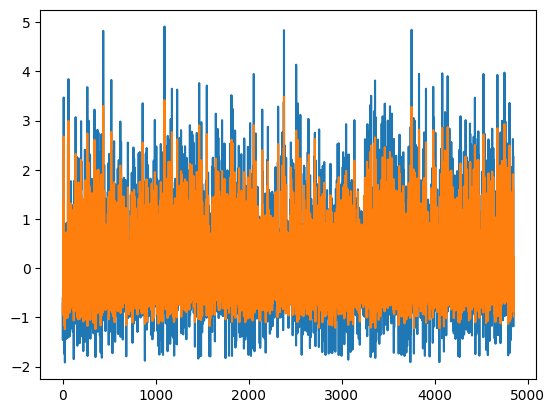

In [6]:
"""Apply AE latent-delatent the data as sanity check"""

ae_dataset = train_dataset #val_dataset
loader     = DataLoader(ae_dataset, batch_size=ae_batch_size, shuffle=False)

autoencoder.eval()
latents        = []
reconstructed  = []
X_input_batches= []

with torch.no_grad():
    for batch in loader:
        x_input = batch[0].to(device)
        latent  = autoencoder.encode_to_latent(x_input)
        x_output= autoencoder.decode_from_latent(latent)
        latents.append(latent.cpu())
        reconstructed.append(x_output.cpu())
        X_input_batches.append(x_input.cpu())

latents      = torch.cat(latents, dim=0)
reconstructed= torch.cat(reconstructed, dim=0)
X_input      = torch.cat(X_input_batches, dim=0)

print(torch.mean(X_input))
print(torch.mean(reconstructed))
MAE = Losses.compute_MAE_loss(X_input, reconstructed)
print(MAE)

variate_to_plot = 1
plt.plot(X_input[:, variate_to_plot])
plt.plot(reconstructed[:, variate_to_plot])


In [7]:
# """Hyperparameter search for AE"""
# from itertools import product

# param_grid = {
#     'layer1_dim':     [21],
#     'layer2_dim':   [9],
#     'latent_dim':     [4],
#     'dropout_prob':   [0.15],
#     'optimizer_lr':   [0.0011],
#     'batch_size':     [122, 124,126, 128, 130, 132, 134]
# }
# # Best AE params: (21, 9, 4, 0.15, 0.0011, 128)
# # Best AE params: (22, 9, 4, 0.15, 0.0011, 128)

# results = []
# for hd, ed, ld, dp, lr, bs in product(param_grid['layer1_dim'],
#                                       param_grid['layer2_dim'],
#                                       param_grid['latent_dim'],
#                                       param_grid['dropout_prob'],
#                                       param_grid['optimizer_lr'],
#                                       param_grid['batch_size']):
#     train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
#     val_loader   = DataLoader(val_dataset, batch_size=bs, shuffle=False)

#     autoencoder = ae.Autoencoder(input_size, hd, ed, ld, dp).to(device)
#     optimizer   = torch.optim.AdamW(autoencoder.parameters(), lr=lr, weight_decay=ae_weight_decay)
#     scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, ae_scheduler_mode,
#                                                              patience=ae_scheduler_patience,
#                                                              factor=ae_scheduler_factor)
#     trainer  = ae.TrainAutoencoder()
#     val_loss = trainer.train_autoencoder(device, autoencoder, ae_training_epochs,
#                                          train_loader, optimizer, scheduler,
#                                          validation_loader=val_loader,
#                                          patience=ae_training_patience)
#     results.append(((hd, ed, ld, dp, lr, bs), val_loss))

# best_params = min(results, key=lambda x: x[1])[0]
# print(f"Best AE params: {best_params}")


In [8]:
"""Training wavestitch diffusion (from training_wavestitch.py)"""

# Diffusion data prep
d_vals_tensor   = from_numpy(training_df.values.astype(np.float32))
training_samples= d_vals_tensor.unfold(0, window_size, 1).transpose(1, 2)
in_dim          = training_df.shape[1]
out_dim         = in_dim - len(hierarchical_column_indices)

# Dataset and model
training_dataset = MyDataset(training_samples.float())
args = {'backbone': backbone, 'beta_0': beta_0, 'beta_T': beta_T,
        'timesteps': timesteps, 'hdim': hdim, 'lr': lr, 'batch_size': batch_size, 'epochs': epochs, 'layers': layers,
        'window_size': window_size, 'stride': stride, 'num_res_layers': num_res_layers, 'res_channels': res_channels,
        'skip_channels': skip_channels, 'diff_step_embed_in': diff_step_embed_in, 'diff_step_embed_mid': diff_step_embed_mid,
        'diff_step_embed_out': diff_step_embed_out, 's4_lmax': s4_lmax, 's4_dstate': s4_dstate, 's4_dropout': s4_dropout,
        's4_bidirectional': s4_bidirectional, 's4_layernorm': s4_layernorm, 'propCycEnc': propCycEnc}
args      = SimpleNamespace(**args)
model     = fetchModel(in_dim, out_dim, args).to(device)
diffusion_config = fetchDiffusionConfig(args)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
dataloader= DataLoader(training_dataset, batch_size=batch_size, shuffle=True)

# Get non-hierarchical columns
all_indices      = np.arange(len(training_df.columns))
remaining_indices= np.setdiff1d(all_indices, hierarchical_column_indices)
non_hier_cols    = np.array(remaining_indices)

def diffusion_training_loop(epochs, dataloader, device, diffusion_config, non_hier_cols, model, optimizer, criterion):
    """Training loop"""
    for epoch in range(epochs):
        total_loss = 0.0
        for batch in dataloader:
            batch = batch.to(device)
            t     = torch.randint(diffusion_config['T'], (batch.shape[0],), device=device)
            sigmas    = torch.randn(batch.shape, device=device)
            alpha_bars= diffusion_config['alpha_bars'].to(device)
            coeff_1   = sqrt(alpha_bars[t]).reshape((len(t), 1, 1))
            coeff_2   = sqrt(1 - alpha_bars[t]).reshape((len(t), 1, 1))
            conditional_mask = torch.ones(batch.shape, device=device)
            conditional_mask[:, :, non_hier_cols] = 0
            batch_noised = (1 - conditional_mask) * (coeff_1 * batch + coeff_2 * sigmas) + conditional_mask * batch
            batch_noised = batch_noised.to(device)
            t = t.reshape((-1, 1))
            sigmas_predicted = model(batch_noised, t)
            optimizer.zero_grad()
            sigmas_permuted = sigmas[:, :, non_hier_cols].permute((0, 2, 1)).to(device)
            loss = criterion(sigmas_predicted, sigmas_permuted)
            loss.backward()
            total_loss += loss.item()
            optimizer.step()
        if (epoch+1) % 10 == 0:
            print(f'epoch: {epoch}/{epochs}, loss: {total_loss}')
    return total_loss

total_loss = diffusion_training_loop(epochs, dataloader, device, diffusion_config, non_hier_cols, model, optimizer, criterion)


# Save model
path     = f'saved_models/{dataset}/'
filename = "model_prop.pth" if propCycEnc else "model.pth"
filepath = os.path.join(path, filename)
os.makedirs(path, exist_ok=True)
torch.save(model.state_dict(), filepath)


epoch: 9/100, loss: 21.104689612984657
epoch: 19/100, loss: 18.60869751870632
epoch: 29/100, loss: 18.640371337532997
epoch: 39/100, loss: 17.975688084959984
epoch: 49/100, loss: 16.85746168345213
epoch: 59/100, loss: 16.542703241109848
epoch: 69/100, loss: 15.116371437907219
epoch: 79/100, loss: 15.690874740481377
epoch: 89/100, loss: 15.023675933480263
epoch: 99/100, loss: 14.204495072364807


In [9]:
# """Hyperparameter search for diffusion"""

# from itertools import product
# import torch.optim as optim
# import copy

# # --- Param grid ---
# param_grid = {
#     'hdim': [64, 128],
#     'lr': [1e-4, 5e-4],
#     'batch_size': [32, 64],
#     'layers': [2, 3],
#     'res_channels': [32, 64],}
# # Best config: {'hdim': 64, 'lr': 0.0005, 'batch_size': 64, 'layers': 2, 'res_channels': 32}

# grid = list(product(*param_grid.values()))
# param_keys = list(param_grid.keys())

# # --- Early stopping ---
# early_patience = 5

# # --- Tracking ---
# best_loss = float('inf')
# best_config = None
# best_model_state = None

# # --- Search loop ---
# for values in grid:
#     config = dict(zip(param_keys, values))
#     print(f"\nTesting config: {config}")

#     model      = fetchModel(in_dim, out_dim, args).to(device)
#     optimizer  = optim.Adam(model.parameters(), lr=lr)
#     dataset    = MyDataset(training_samples.float())
#     dataloader = DataLoader(dataset, batch_size= batch_size, shuffle=True)
#     criterion  = nn.MSELoss()
#     best_val   = float('inf')
#     patience   = 0

#     for epoch in range(epochs):
#         model.train()
#         total_loss = 0.0
#         for batch in dataloader:
#             batch  = batch.to(device)
#             t      = torch.randint(diffusion_config['T'], (batch.shape[0],), device=device)
#             sigmas = torch.randn(batch.shape, device=device)
#             alpha_bars = diffusion_config['alpha_bars'].to(device)
#             coeff_1 = torch.sqrt(alpha_bars[t]).reshape((len(t), 1, 1))
#             coeff_2 = torch.sqrt(1 - alpha_bars[t]).reshape((len(t), 1, 1))
#             conditional_mask = torch.ones(batch.shape, device=device)
#             conditional_mask[:, :, non_hier_cols] = 0
#             batch_noised = (1 - conditional_mask) * (coeff_1 * batch + coeff_2 * sigmas) + conditional_mask * batch
#             t = t.reshape((-1, 1))
#             sigmas_pred  = model(batch_noised, t)
#             optimizer.zero_grad()
#             sigmas_perm= sigmas[:, :, non_hier_cols].permute((0, 2, 1))
#             loss       = criterion(sigmas_pred, sigmas_perm)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         avg_loss = total_loss / len(dataloader)
#         if epoch%5 ==0:
#             print(f"Epoch {epoch+1}: loss = {avg_loss:.6f}")

#         # Early stopping
#         if avg_loss < best_val:
#             best_val = avg_loss
#             patience = 0
#         else:
#             patience += 1
#             if patience >= early_patience:
#                 print("Early stopping")
#                 break

#     # Track best overall
#     if best_val < best_loss:
#         best_loss = best_val
#         best_config = config
#         best_model_state = copy.deepcopy(model.state_dict())

# # --- Done ---
# print(f"\nBest config: {best_config}")
# print(f"Best loss: {best_loss:.6f}")

# # Save best model
# os.makedirs("saved_models/hparam_search", exist_ok=True)
# torch.save(best_model_state, "saved_models/hparam_search/best_model.pth")


In [10]:
# # Run synthesizer to get fake data (using terminal)
# !python wavestitch_synthesizer.py -dataset RossmanSales -synth_mask C


In [ ]:
"""Synthesize samples using Wavestitch [from wavestitch_synthesizer.py]"""

from training_utils import MyDataset, fetchModel, fetchDiffusionConfig
from metasynth import metadataMask

class Args:
    backbone            = backbone
    beta_0              = beta_0
    beta_T              = beta_T
    timesteps           = timesteps
    num_res_layers      = num_res_layers
    res_channels        = res_channels
    skip_channels       = skip_channels
    diff_step_embed_in  = diff_step_embed_in
    diff_step_embed_mid = diff_step_embed_mid
    diff_step_embed_out = diff_step_embed_out
    s4_lmax             = s4_lmax
    s4_dstate           = s4_dstate
    s4_dropout          = s4_dropout
    s4_bidirectional    = s4_bidirectional
    s4_layernorm        = s4_layernorm

args   = Args()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Helper ---
def decimal_places(series):
    return series.apply(lambda x: len(str(x).split('.')[1]) if '.' in str(x) else 0).max()

def create_pipelined_noise(test_batch, stride, window_size):
    sampled = torch.normal(0, 1, (stride * (test_batch.shape[0]-1) + window_size, test_batch.shape[2]))
    return sampled.unfold(0, window_size, stride).transpose(1, 2)

# --- Load Data ---
np.random.seed(random_seed)
torch.manual_seed(random_seed)

preprocessor      = Preprocessor(dataset, propCycEnc)
df                = preprocessor.df_cleaned
end               = preprocessor.test_indices[-1]
start             = preprocessor.test_indices[0]
window_count      = ((end + 1 - window_size - start) // stride) + 1
tilde_start       = end + 1 - window_size - (window_count * stride)
additional_indices= start - tilde_start
test_df           = df.loc[preprocessor.train_indices[-additional_indices:] + preprocessor.test_indices]
test_df_with_hierarchy = preprocessor.cyclicDecode(test_df)
decimal_accuracy  = {k: decimal_places(preprocessor.df_orig[k])
                     for k in test_df_with_hierarchy.columns}
metadata     = test_df_with_hierarchy[preprocessor.hierarchical_features_uncyclic]
rows_to_synth= metadataMask(metadata, synth_mask, dataset)
real_df      = test_df_with_hierarchy[rows_to_synth]
df_synth     = test_df.copy()

# --- Model Prep ---
d_vals   = df_synth.values
m_vals   = rows_to_synth.values
d_tensor = from_numpy(d_vals)
m_tensor = from_numpy(m_vals)
windows  = d_tensor.unfold(0, window_size, stride).transpose(1, 2)
masks    = m_tensor.unfold(0, window_size, stride)
hierarchical_column_indices = df_synth.columns.get_indexer(preprocessor.hierarchical_features_cyclic)

non_hier_cols   = np.setdiff1d(np.arange(len(df_synth.columns)), hierarchical_column_indices)
test_dataset    = MyDataset(windows.float())
mask_dataset    = MyDataset(masks)
model           = fetchModel(len(df_synth.columns), len(non_hier_cols), args).to(device)
diffusion_config= fetchDiffusionConfig(args)
test_loader     = DataLoader(test_dataset, batch_size=batch_size)
mask_loader     = DataLoader(mask_dataset, batch_size=batch_size)
model_path      = f'saved_models/{dataset}/model_prop.pth' if propCycEnc else f'saved_models/{dataset}/model.pth'
saved_params    = torch.load(model_path, map_location=device)

with torch.no_grad():
    for name, param in model.named_parameters():
        param.copy_(saved_params[name])
        param.requires_grad = False
model.eval()

real_df_out = preprocessor.rescale(real_df).reset_index(drop=True).round(decimal_accuracy)
path        = f'generated/{dataset}/{synth_mask}/'
os.makedirs(path, exist_ok=True)
real_path   = os.path.join(path, 'real.csv')
if not os.path.exists(real_path):
    real_df_out.to_csv(real_path)

# --- Inference ---

def synthesize_samples(input_dataset, n_trials, device, test_loader, mask_loader, stride, window_size,
                       hierarchical_column_indices, diffusion_config, non_hier_cols, model, rows_to_synth,
                       preprocessor, decimal_accuracy, propCycEnc, path):
    """Wavestitch conditional synthesis, and writes to csv file for eacn trial"""

    def _apply_mask(cached, test_batch, mask_batch):
        mask_exp = torch.zeros_like(test_batch, dtype=torch.bool)
        mask_exp[:, :, non_hier_cols] = mask_batch.unsqueeze(-1)
        masked = test_batch.clone()
        masked[~mask_exp] = cached[~mask_exp]
        return masked, mask_exp

    def _denoise(x, eps, ab_t, at, b_t, ab_t1, step):
        vari = 0.0
        if step > 0:
            vari = b_t * ((1 - ab_t1) / (1 - ab_t)) * torch.randn_like(eps)
        x_out = x.clone()
        x_out[:, :, non_hier_cols] = (x[:, :, non_hier_cols] - ((b_t / torch.sqrt(1 - ab_t)) * eps)) / torch.sqrt(at)
        x_out[:, :, non_hier_cols] += vari
        return x_out

    num_ops, exec_times = 0, []
    df_cols    = preprocessor.df_cleaned.columns
    mask_np    = rows_to_synth.to_numpy() if hasattr(rows_to_synth, "to_numpy") else np.array(rows_to_synth)
    file_suffix= 'cycProp' if propCycEnc else 'cycStd'

    for trial in range(n_trials):
        start_time  = timer()
        synth_tensor= torch.empty(0, input_dataset.inputs.shape[2]).to(device)

        for idx, (test_batch, mask_batch) in enumerate(zip(test_loader, mask_loader)):
            test_batch, mask_batch = test_batch.to(device), mask_batch.to(device)
            noise = create_pipelined_noise(test_batch, stride, window_size).to(device)
            x     = noise.clone()
            x[:, :, hierarchical_column_indices] = test_batch[:, :, hierarchical_column_indices]

            for step in reversed(range(diffusion_config['T'])):
                ab_t         = diffusion_config['alpha_bars'][step].to(device)
                ab_t1        = diffusion_config['alpha_bars'][step - 1].to(device) if step > 0 else None
                at           = diffusion_config['alphas'][step].to(device)
                b_t          = diffusion_config['betas'][step].to(device)
                sampled_noise= create_pipelined_noise(test_batch, stride, window_size).to(device)
                cached       = torch.sqrt(ab_t) * test_batch + torch.sqrt(1 - ab_t) * sampled_noise
                x, mask_exp  = _apply_mask(cached, test_batch, mask_batch)
                x[:, :, hierarchical_column_indices] = test_batch[:, :, hierarchical_column_indices]
                times        = torch.full((test_batch.shape[0], 1), step).to(device)
                eps          = model(x, times).permute(0, 2, 1)
                norm_denoised= _denoise(x, eps, ab_t, at, b_t, ab_t1, step)
                x[mask_exp]  = norm_denoised[mask_exp]
                x[~mask_exp] = test_batch[~mask_exp]
                x[1:, :window_size - stride, :] = x.roll(1, 0)[1:, stride:window_size, :]
                if trial == 0:
                    num_ops += 1
            gen = torch.cat((x[0], x[1:, window_size - stride:, :].reshape(-1, x.shape[2]))) if idx == 0 \
                else x[:, window_size - stride:, :].reshape(-1, x.shape[2])
            synth_tensor = torch.cat((synth_tensor, gen), dim=0)
        exec_times.append(timer() - start_time)

        df_synth    = pd.DataFrame(synth_tensor.cpu().numpy(), columns=df_cols)
        synth_df_out= preprocessor.decode(df_synth, rescale=True)[mask_np].round(decimal_accuracy)
        out_path    = f'{path}synth_hyacinth_pipeline_stride_{stride}_trial_{trial}_{file_suffix}.csv'
        synth_df_out.to_csv(out_path)
        print(f"File {trial+1}/{n_trials} done")
        if trial == 0:
            with open(f'{path}denoiser_calls_pipeline_stride_{stride}_{file_suffix}.txt', 'w') as f:
                f.write(str(num_ops))
    return synth_df_out, exec_times

synth_df_out, exec_times= synthesize_samples(test_dataset, n_trials, device, test_loader, mask_loader, stride, window_size, hierarchical_column_indices, 
                                             diffusion_config, non_hier_cols, model, rows_to_synth, preprocessor, decimal_accuracy, propCycEnc, path)

with open(f'generated/{dataset}/{synth_mask}/denoiser_calls_pipeline_stride_{stride}_cycStd.txt', 'a') as f:
    arr_time = np.array(exec_times)
    f.write('\n' + str(np.mean(arr_time)) + '\n' + str(np.std(arr_time)))


File 1/5 done
File 2/5 done
File 3/5 done
File 4/5 done
File 5/5 done


In [16]:
print(synth_df_out.mean())
# Sales        8111.763802
# Customers     951.133751
# Year         2015.000000
# Month           4.019351
# Day            15.997723
# Store           5.501992
# dtype: float64


Sales        6424.937393
Customers     713.404098
Year         2015.000000
Month           4.019351
Day            15.997723
Store           5.501992
dtype: float64


In [ ]:
"""LDM"""

training_df_tensor = torch.tensor(training_df.values, dtype=torch.float32).to(device)
latent  = autoencoder.encode_to_latent(x_input)

# %%%%%%%%%%%%%%%%%%

# --- Inference ---
num_ops    = 0
exec_times = []

for trial in range(n_trials):
    start_time   = timer()
    synth_tensor = torch.empty(0, training_df_tensor.inputs.shape[2]).to(device)
    for idx, (test_batch, mask_batch) in enumerate(zip(test_loader, mask_loader)):
        test_batch = test_batch.to(device)
        mask_batch = mask_batch.to(device)
        x = create_pipelined_noise(test_batch, stride, window_size).to(device)
        x[:, :, hierarchical_column_indices] = test_batch[:, :, hierarchical_column_indices]
        for step in range(diffusion_config['T'] - 1, -1, -1):
            times = torch.full((test_batch.shape[0], 1), step).to(device)
            ab_t  = diffusion_config['alpha_bars'][step].to(device)
            ab_t1 = diffusion_config['alpha_bars'][step - 1].to(device) if step > 0 else None
            at    = diffusion_config['alphas'][step].to(device)
            b_t   = diffusion_config['betas'][step].to(device)
            sampled_noise= create_pipelined_noise(test_batch, stride, window_size).to(device)
            cached       = torch.sqrt(ab_t) * test_batch + torch.sqrt(1 - ab_t) * sampled_noise
            mask_exp     = torch.zeros_like(test_batch, dtype=bool)
            for c in non_hier_cols:
                mask_exp[:, :, c] = mask_batch
            x[~mask_exp] = cached[~mask_exp]
            x[:, :, hierarchical_column_indices] = test_batch[:, :, hierarchical_column_indices]
            eps  = model(x, times).permute(0, 2, 1)
            vari = 0.0
            if step > 0:
                vari = b_t * ((1 - ab_t1) / (1 - ab_t)) * torch.normal(0, 1, size=eps.shape).to(device)
            norm_denoised = create_pipelined_noise(test_batch, stride, window_size).to(device)
            norm_denoised[:, :, non_hier_cols] = (x[:, :, non_hier_cols] - ((b_t / torch.sqrt(1 - ab_t)) * eps)) / torch.sqrt(at)
            norm_denoised[:, :, non_hier_cols] += vari
            x[mask_exp]  = norm_denoised[mask_exp]
            x[~mask_exp] = test_batch[~mask_exp]
            x[1:, : (window_size - stride), :] = x.roll(1, 0)[1:, stride: window_size, :]
            if trial == 0:
                num_ops += 1
        if idx == 0:
            generated = torch.cat((x[0], x[1:, (window_size - stride):, :].reshape(-1, x.shape[2])), dim=0)
        else:
            generated = x[:, (window_size - stride):, :].reshape(-1, x.shape[2])
        synth_tensor  = torch.cat((synth_tensor, generated), dim=0)

    exec_times.append(timer() - start_time)
    df_synthesized = pd.DataFrame(synth_tensor.cpu().numpy(), columns=df.columns)
    # synth_df_out   = preprocessor.decode(df_synthesized, rescale=True)[rows_to_synth.reset_index(drop=True)].round(decimal_accuracy)
    mask         = rows_to_synth.to_numpy() if hasattr(rows_to_synth, "to_numpy") else np.array(rows_to_synth)
    synth_df_out = preprocessor.decode(df_synthesized, rescale=True)[mask].round(decimal_accuracy)
    file_suffix  = 'cycProp' if propCycEnc else 'cycStd'
    synth_df_out.to_csv(f'{path}synth_hyacinth_pipeline_stride_{stride}_trial_{trial}_{file_suffix}.csv')
    if trial == 0:
        with open(f'{path}denoiser_calls_pipeline_stride_{stride}_{file_suffix}.txt', 'w') as f:
            f.write(str(num_ops))
# %%%%%%%%%%%%%%%%%

x_output= autoencoder.decode_from_latent(latent)


# =========================================================
ae_dataset = train_dataset #val_dataset # 
loader     = DataLoader(ae_dataset, batch_size=ae_batch_size, shuffle=False)

autoencoder.eval()
latents        = []
reconstructed  = []
X_input_batches= []

with torch.no_grad():
    for batch in loader:
        x_input = batch[0].to(device)
        latent  = autoencoder.encode_to_latent(x_input)
        x_output= autoencoder.decode_from_latent(latent)
        latents.append(latent.cpu())
        reconstructed.append(x_output.cpu())
        X_input_batches.append(x_input.cpu())

latents      = torch.cat(latents, dim=0)
reconstructed= torch.cat(reconstructed, dim=0)
X_input      = torch.cat(X_input_batches, dim=0)

print(torch.mean(X_input))
print(torch.mean(reconstructed))
MAE = Losses.compute_MAE_loss(X_input, reconstructed)
print(MAE)

variate_to_plot = 1
plt.plot(X_input[:, variate_to_plot])
plt.plot(reconstructed[:, variate_to_plot])


AttributeError: 'Tensor' object has no attribute 'inputs'

In [ ]:
selected_df = synth_df_out #df_synth
for i in range(selected_df.shape[1]):
    ok = max(selected_df.iloc[:,i])
    print(ok)

# df, training_df, test_df, real_df, df_synth

NameError: name 'synth_df_out' is not defined

<Axes: >

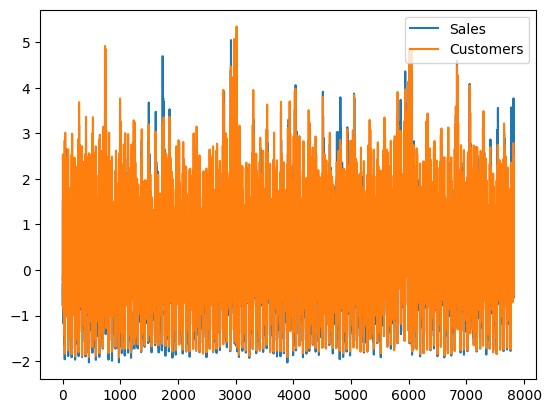

In [ ]:
df_generated = pd.read_csv(f"generated/{dataset}/{synth_mask}/synth_hyacinth_pipeline_stride_1_trial_3_cycStd.csv")
# df_generated.iloc[:, [1,2]].plot()
df.iloc[:, [0,1]].plot()


In [ ]:
# real_df_out.head
synth_df_out.head


<bound method NDFrame.head of       Sales  Customers  Year  Month  Day  Store
1      6663        880  2015      1    2      1
2      8455        858  2015      1    2      2
3      8579       1048  2015      1    2      3
4      8572       1288  2015      1    2      4
5      7882        834  2015      1    2      5
...     ...        ...   ...    ...  ...    ...
1753   8529       1110  2015      7   31      6
1754  11805       1268  2015      7   31      7
1755   9980       1221  2015      7   31      8
1756   9723        907  2015      7   31      9
1757  11275       1414  2015      7   31     10

[1757 rows x 6 columns]>

In [ ]:
"""Metrics for synthetic data quality"""

# Prepare data
X_real  = real_df_out.values.astype(np.float32)
X_synth = synth_df_out.values.astype(np.float32)

# Split + scale data
X_train, X_val= train_test_split(X_real, test_size=0.2, random_state=42)
scaler        = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_val_scaled  = scaler.transform(X_val)
X_synth_scaled= scaler.transform(X_synth)

# Convert to tensors + build datasets
X_train_tensor = torch.tensor(X_train_scaled)
X_val_tensor   = torch.tensor(X_val_scaled)
X_synth_tensor = torch.tensor(X_synth_scaled, dtype=torch.float32).to(device)
train_dataset  = TensorDataset(X_train_tensor, torch.zeros(len(X_train_tensor)))
val_dataset    = TensorDataset(X_val_tensor, torch.zeros(len(X_val_tensor)))

# Load hyperparams from config
with open('../params.yaml', 'r') as file:
    yaml_config = yaml.safe_load(file)
layer1_dim        = yaml_config['autoencoder_design']['layer1_dim']
layer2_dim        = yaml_config['autoencoder_design']['layer2_dim']
latent_dim        = yaml_config['autoencoder_design']['latent_dim']
dropout_prob      = yaml_config['autoencoder_design']['dropout_prob']
ae_training_epochs= 100#yaml_config['autoencoder_training']['training_epochs']
batch_size        = yaml_config['autoencoder_training']['batch_size']
optimizer_lr      = yaml_config['autoencoder_training']['optimizer_lr']
weight_decay      = yaml_config['autoencoder_training']['weight_decay']
training_patience = yaml_config['autoencoder_training']['training_patience']
scheduler_patience= yaml_config['autoencoder_training']['scheduler_patience']
scheduler_mode    = yaml_config['autoencoder_training']['scheduler_mode']
scheduler_factor  = yaml_config['autoencoder_training']['scheduler_factor']

# Training setup
device      = ae.device
input_size  = X_train_tensor.shape[1] # num of features
train_loader= DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader  = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
autoencoder = ae.Autoencoder(input_size, layer1_dim, layer2_dim, latent_dim, dropout_prob).to(device)
optimizer   = torch.optim.AdamW(autoencoder.parameters(), lr=optimizer_lr, weight_decay=weight_decay)
scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, scheduler_mode, patience=scheduler_patience, factor=scheduler_factor)

# Train AE
trainer = ae.TrainAutoencoder()
trainer.train_autoencoder(device, autoencoder, ae_training_epochs, train_loader, optimizer, scheduler,
                          validation_loader=val_loader, patience=training_patience)

# Make latents + reconstruction (optional)
autoencoder.eval()
with torch.no_grad():
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    real_latents = autoencoder.encode_to_latent(X_val_tensor).cpu().numpy()
    synth_latents= autoencoder.encode_to_latent(X_synth_tensor).cpu().numpy()
    # X_reconstructed = autoencoder(X_train_tensor.to(device)).cpu().numpy()


Early stopping triggered


In [ ]:
print(real_latents.shape)
print(synth_latents.shape)
FID_distance = get_frechet_distance(real_latents, synth_latents)
print(FID_distance)


(352, 6)
(1757, 6)
0.39453114556124647


t-SNE done.
UMAP done.


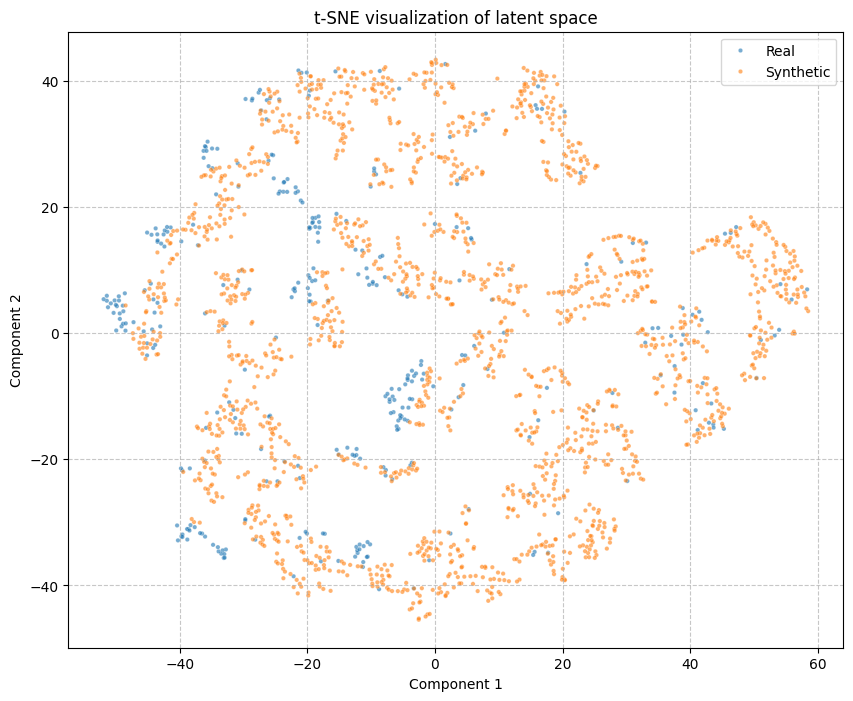

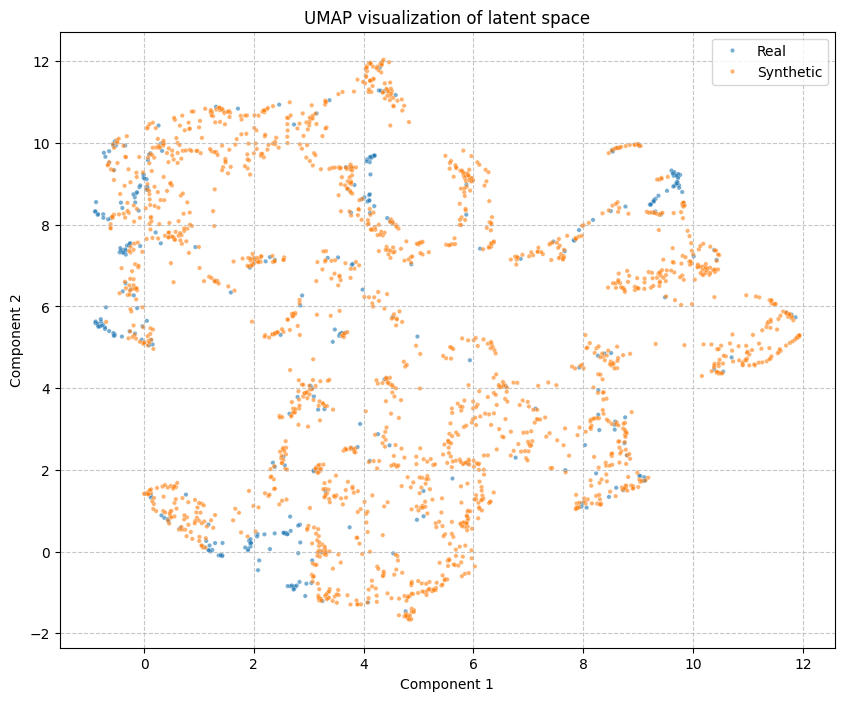

In [ ]:
"""t-SNE/UMAP"""

import seaborn as sns
from sklearn.manifold import TSNE
import umap

if isinstance(real_latents, torch.Tensor):
    real_latents = real_latents.cpu().numpy()
if isinstance(synth_latents, torch.Tensor):
    synth_latents = synth_latents.cpu().numpy()

# 1. Combine Latents and Create Labels
all_latents= np.vstack((real_latents, synth_latents))
labels     = ['Real'] * len(real_latents) + ['Synthetic'] * len(synth_latents)
labels_np  = np.array(labels) # Convert labels to np (easier indexing)

# 2. Apply t-SNE
# n_components: 2 for 2D plot, 3 for 3D plot
# perplexity: controls balance between local and global aspects of data (often 5-50)
# n_iter: number of iterations for optimization
tsne_results = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, learning_rate='auto').fit_transform(all_latents)
print("t-SNE done.")

# 3. Apply UMAP
# n_neighbors: balances local vs. global structure (smaller for local, larger for global)
# min_dist: controls how tightly points are packed together
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = reducer.fit_transform(all_latents)
print("UMAP done.")

# 4. Plotting
def plot_latent_space(embedding, labels, title):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels,
                    palette=['#1f77b4', '#ff7f0e'], s=10, alpha=0.6, legend='full')
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
plot_latent_space(tsne_results, labels_np, 't-SNE visualization of latent space')
plot_latent_space(umap_results, labels_np, 'UMAP visualization of latent space')

# # To make 3D plots, set n_components=3
# from mpl_toolkits.mplot3d import Axes3D
# def plot_latent_space_3d(embedding, labels, title):
#     fig = plt.figure(figsize=(10, 8))
#     ax = fig.add_subplot(111, projection='3d')
#     colors = {'Real': '#1f77b4', 'Synthetic': '#ff7f0e'}
#     for label_val in np.unique(labels):
#         idx = (labels == label_val)
#         ax.scatter(embedding[idx, 0], embedding[idx, 1], embedding[idx, 2],
#                    color=colors[label_val], label=label_val, s=10, alpha=0.6)
#     ax.set_title(title)
#     ax.set_xlabel('Component 1')
#     ax.set_ylabel('Component 2')
#     ax.set_zlabel('Component 3')
#     ax.legend()
#     plt.show()
# tsne_results_3d = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42, learning_rate='auto').fit_transform(all_latents)
# umap_results_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(all_latents)
# plot_latent_space_3d(tsne_results_3d, labels_np, 't-SNE 3D Visualization of Latent Space')
# plot_latent_space_3d(umap_results_3d, labels_np, 'UMAP 3D Visualization of Latent Space')
